# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
#import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos)
print(usage.isna().mean()) # Proporción de valores nulos)


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  - Indica qué harías: ¿imputar, eliminar, ignorar?

**users**  
1) city - 469 - 11.73%
   Se recomienda investigar para decidir si imputar, dejar como nulo, o clasificarla como Desconocida
3) churn_date - 3534 - 88.35%
   No se recomienda elimininar ni imputar sino dejarla como está ya que implica que el usuario sigue activo, y considerar para el análisis de churn sólo los que no son nulos

 **usage** 
 1) date - 500 - 0.125%
   Se puede dejar como nulo o eliminar por ser muy baja la cantidad
    
 3) duration- 22,07655- 19%
   Se recomienda investigar para decidir si imputar o dejar como nulo, cruzando con type
    
 5) length- 17,89644 - 74%
   Se recomienda investigar para decidir si imputar o dejar como nulo, cruzando con type
 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... es identificador único y no presenta nulos. No aporta información de negocio por sí misma; solo sirve para identificar registros.
- La columna `age` ... No presenta  nulos pero si una desviación estándar muy alta (123.2), lo cual es una señal de alerta inmediata, observándose que el valor -999 en min es un outlier que está distorsionando los cálculos.


In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...No presentan nulos y son identificadores sin valor analítico propio

- La columnas `duration` ... Presenta una diferencia entre media y mediana, junto con un máximo bastante más alto que el percentil 75 (6.99) lo que sugiere presencia de outliers o eventos de duración inusualmente largos

- La columnas `length`..Presenta un máximo notablemente alto comparado con el percentil 75, lo que indica outliers importantes o una cola larga a la derecha.

Es reomendable revisar los valores extremos con un boxplot  


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [15]:
for col in columnas_user: 
    print(col)
    print("Frecuencia absoluta")
    print(users[col].value_counts())    
    print("Frecuencia relativa")
    print(users[col].value_counts(normalize=True))     
    print("Categorias diferentes")
    print(users[col].nunique())    
    print("Categoria mas frecuente")
    print(users[col].mode())   
    print()


city
Frecuencia absoluta
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
Categorias diferentes
7
Categoria mas frecuente
0    Bogotá
dtype: object

plan
Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64
Categorias diferentes
2
Categoria mas frecuente
0    Basico
dtype: object



- La columna `city` ... Presenta un problema de calidad de datos por el valor "?" por lo que requiere limpieza previa: unificar "?" con los NaN y decidir una estrategia de imputación o eliminación de registros

- La columna `plan` ...Se encuentra limpia y lista para análisis directo


In [16]:
# explorar columna categórica de usage
usage['type'].describe() 

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [17]:
    print("Frecuencia absoluta")
    print(usage['type'].value_counts())    
    print("Frecuencia relativa")
    print(usage['type'].value_counts(normalize=True))     
    print("Categorias diferentes")
    print(usage['type'].nunique())    
    print("Categoria mas frecuente")
    print(usage['type'].mode())   

Frecuencia absoluta
text    22092
call    17908
Name: type, dtype: int64
Frecuencia relativa
text    0.5523
call    0.4477
Name: type, dtype: float64
Categorias diferentes
2
Categoria mas frecuente
0    text
dtype: object


- La columna `type` ...No presenta nulos ni inconsistencias por lo que no se requiere limpieza adicional sobre esta columna



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?
  
  users -> age - corregir outlier -999
           city - unificar nulos y valor '?'

  usage -> duration - revisar outlier y ajustar valores 
           length - revisar outlier  y ajustar valores 
    

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... Existen registros con años futuros (2026) que deben corregirse

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... No existen registros fuera del año de análisis (2024) 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

La columna `reg_date` de users registra valores viejos (2022 y 2023) y años sin trascurrir (2026), el cual debe marcarse como no aplicable.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year == 2026)

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [31]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [32]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los nulos tanto en duration como en length son consistentes con MAR, ya que la probabilidad de faltante está fuertemente explicada por la variable type.
Cada registro tiene información sólo en la columna que le corresponde según su type. duration es exclusiva de call y length es exclusiva de text, no representan una pérdida de información.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas
2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [33]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_mensajes=('is_text', 'sum'),
    total_llamadas=('is_call', 'sum'),
    total_minutos_llamadas=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'total_mensajes': 'cant_mensajes',
    'total_llamadas': 'cant_llamadas',
    'total_minutos_llamadas': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [35]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [36]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [37]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

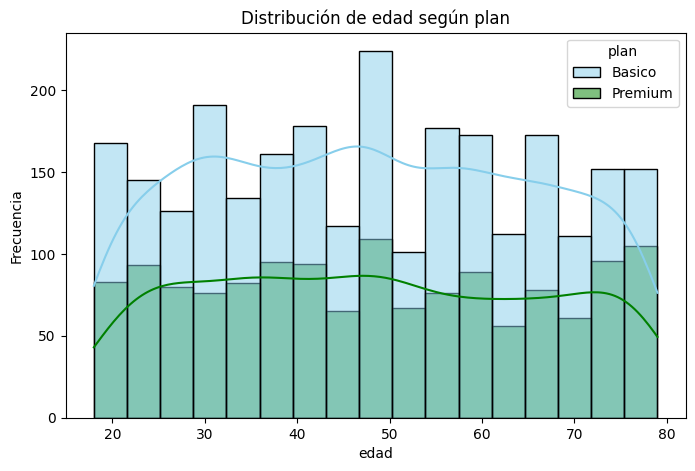

In [38]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile,
        x='age',
        hue='plan',
        palette=['skyblue', 'green'],
        kde=True
)
plt.title(f'Distribución de edad según plan')
plt.xlabel('edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución - Ambos segmentos están distribuidos de forma similar en todos los grupos de edad.
  La edad no parece ser un factor diferenciador en la elección entre plan Básico y Premium

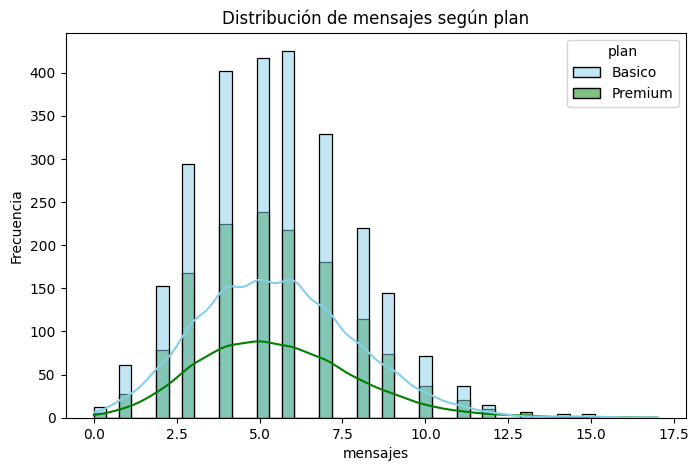

In [39]:
# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile,
        x='cant_mensajes',
        hue='plan',
        palette=['skyblue', 'green'],
        kde=True
)
plt.title(f'Distribución de mensajes según plan')
plt.xlabel('mensajes')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- Distribucion - Se presenta una distribución de formas similares y comparten el mismo pico alrededor de 5-6 mensajes, mostrando un ligeramente sesgo a la derecha (right-skewed)
No existe un patrón diferenciador claro entre plan y cantidad de mensajes enviados

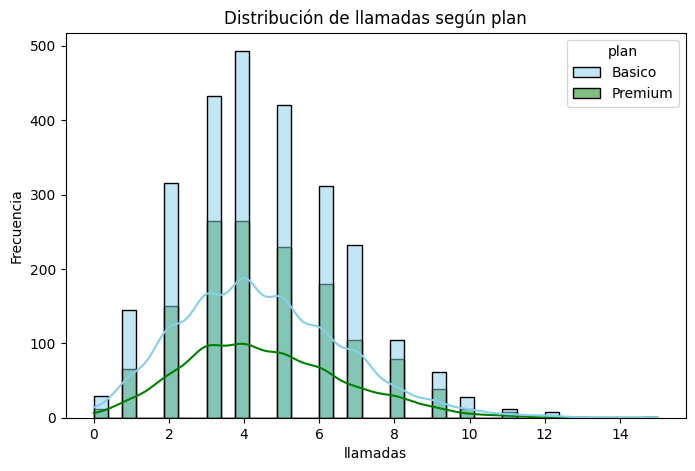

In [40]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile,
        x='cant_llamadas',
        hue='plan',
        palette=['skyblue', 'green'],
        kde=True
)
plt.title(f'Distribución de llamadas según plan')
plt.xlabel('llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución - Se presenta una distribución uniforme, sesgada a la derecha (right-skewed), con el pico concentrado entre 3 y 5 llamadas.
  No se observa un patrón diferenciador entre plan y cantidad de llamadas


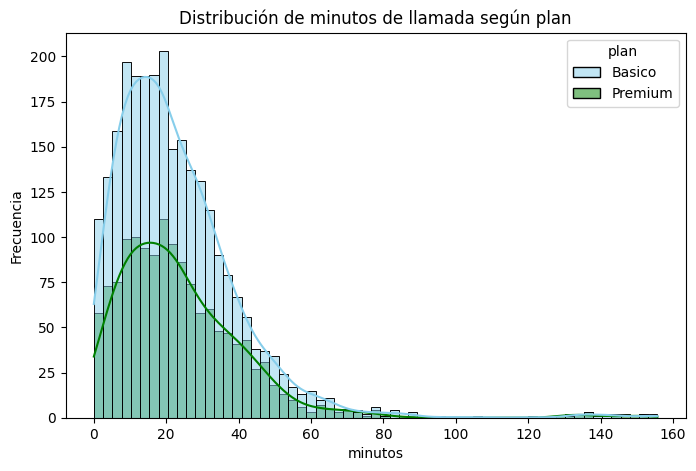

In [41]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile,
        x='cant_minutos_llamada',
        hue='plan',
        palette=['skyblue', 'green'],
        kde=True
)
plt.title(f'Distribución de minutos de llamada según plan')
plt.xlabel('minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribucion - Se presentan formas y picos muy similares pero con un sesgo claramente marcado hacia la derecha (right-skewed), con el pico concentrado entre 10 y 20 minutos, y presencia de posibles outliers en el extremo derecho (incluso más allá de 100 minutos).

Estos gráficos sugieren que la segmentación Básico/Premium no está explicada por patrones de consumo (frecuencia o duración de uso), y que la diferencia entre planes probablemente responde a otros factores no capturados en estas cuatro variables 
 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

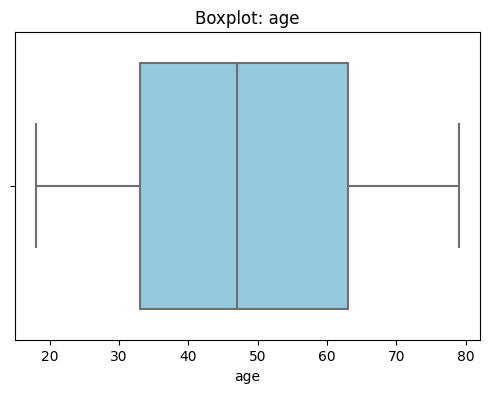

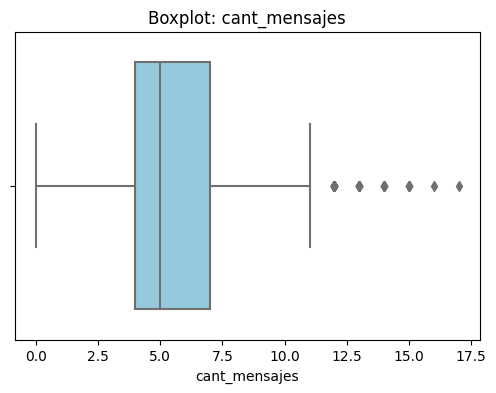

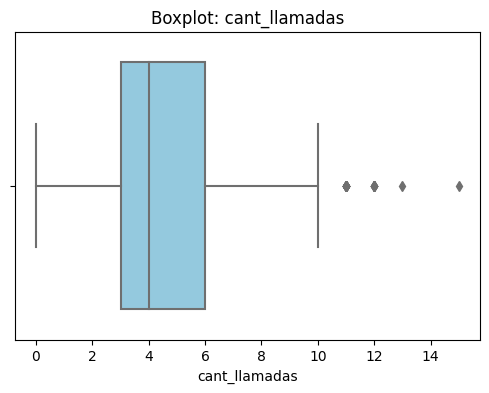

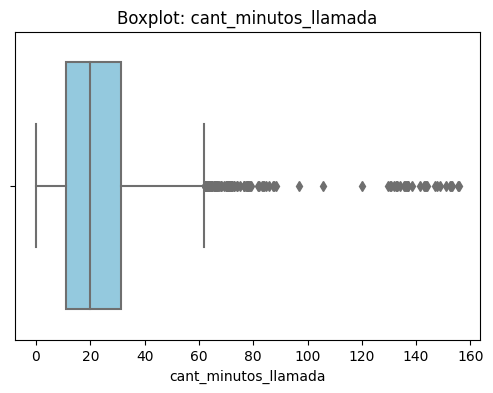

In [44]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- age: No se observan puntos fuera de los bigotes, no hay outliers. La distribución va de ~18 a ~80 años sin valores atípicos.
- cant_mensajes: Presenta outliers del lado superior, con varios puntos por encima de ~11.5 mensajes (aprox. entre 12 y 17). Son relativamente pocos y están moderadamente alejados del bigote superior, no extremos. 
- cant_llamadas: Pesenta outliers del lado superior, con valores entre ~11 y 15 llamadas, con pocos puntos moderadamente alejados del bigote.
- cant_minutos_llamada: Presenta una gran cantidad de puntos por encima de ~62 minutos, extendiéndose hasta ~155 minutos, con una concentración notable entre 80-150. Esto sugiere una subpoblación de usuarios con consumo de llamadas mucho mayor al típico.


In [45]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    limites[col] = limite_superior
    n_outliers = (user_profile[col] > limite_superior).sum()
    print(f"{col}: límite superior = {limite_superior:.2f} | outliers = {n_outliers} ({n_outliers/len(user_profile):.2%})")


cant_mensajes: límite superior = 11.50 | outliers = 46 (1.15%)
cant_llamadas: límite superior = 10.50 | outliers = 30 (0.75%)
cant_minutos_llamada: límite superior = 61.86 | outliers = 109 (2.73%)


In [46]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Se mantienen los outliers porque su efecto sobre la media es mínimo (diferencia de solo 0.52 respecto a la mediana), por lo que no distorsionan significativamente el resumen estadístico. El std (2.36) es razonable en relación a la media — coeficiente de variación ≈ 0.43, dispersión moderada, no hay señal de descontrol estadístico.

- cant_llamadas: mantener o no outliers, porqué?
Se mantienen los outliers porque la media Media (4.48) también es ligeramente mayor que la mediana (4.00), y el Std (2.14), coeficiente de variación ≈ 0.48, dispersión similar a cant_mensajes, los valores extremos no comprometen la representatividad del promedio.

- cant_minutos_llamada: mantener o no outliers, porqué?
Se considera tratamiento de outliers - Media notablemente mayor que la mediana (23.32 Vs 19.78), consistente con tener la mayor proporción de outliers (2.73%) y el rango más amplio (0 a 155.69). El Std (18.17) es muy alto en relación a la media (coeficiente de variación ≈ 0.78), indicando alta dispersión.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  

- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


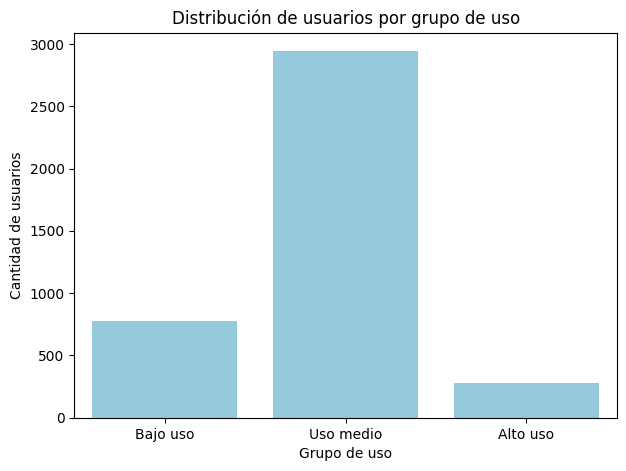

In [51]:
# Visualización de los segmentos por uso

plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


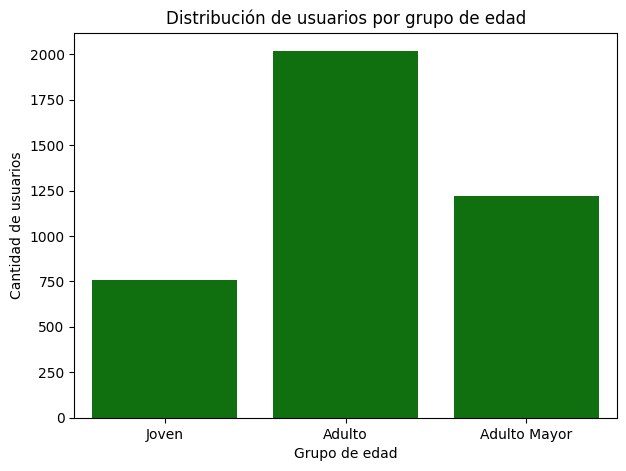

In [52]:
# Visualización de los segmentos 
por edad


plt.figure(figsize=(7, 5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='green')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

---
**Insight Ejecutivo para Stakeholders**

1. CALIDAD DE LOS DATOS ORIGINALES
- city: Registros con valores faltantes (NaN) y captura inválida '?'
- age: Registros con valor sentinel -999
- reg_date: Tipo de dato inconsistente y registros con fecha inválida futura (2026)
- duration: Registros con nulos aparentes
- length: Registros con nulos aparentes
   
2. SEGMENTOS IDENTIFICADOS: EDAD × NIVEL DE USO
Se construyeron dos ejes de segmentación:
- grupo_edad: Joven (<30), Adulto (30-59), Adulto Mayor (60+)
- grupo_uso: Bajo uso (<5 llamadas y <5 mensajes), Uso medio (<10 y <10), Alto uso (resto)
El análisis de histogramas mostró que la edad no predice el comportamiento de consumo.
   
3. SEGMENTOS MÁS VALIOSOS PARA CONNECTATEL
- Usuarios de "Alto uso": representan el segmento con mayor consumo de minutos de llamada.
Son por tanto candidatos naturales para planes de mayor valor ya que su comportamiento indica dependencia real del servicio.
-  El plan actual (Básico/Premium) no está segmentando por comportamiento real de uso, y el plan Premium representa solo el 35% de la base, lo que indica que la decisión de compra actual probablemente responde a percepción de valor o precio, no a necesidad de uso.
Esto sugiere una oportunidad comercial para mejorar el targeting comercial desaprovechada.

4. PATRONES DE USO EXTREMO (OUTLIERS)
- cant_mensajes: Grupo pequeño de usuarios con alta actividad de mensajería con bajo impacto estadístico (1.15%)
- cant_llamadas: Grupo mínimo de alta frecuencia de llamadas con bajo impacto estadístico (0.75%)
- cant_minutos_llamadas: Grupo significativo de usuarios con hasta 155 minutos acumulados, muy por encima de la mediana (19.8 min). Representan consumo intensivo real, no errores de captura.
   

5. RECOMENDACIONES ACCIONABLES
- Resolver la calidad de city (14.1% sin dato válido) antes de cualquier estrategia de expansión o marketing geográfico, ya que actualmente limita la confiabilidad de decisiones regionales.
- No usar la edad como criterio de segmentación de producto, dado que no muestra relación con el comportamiento de consumo
- Rediseñar la segmentación de planes en torno a variables reales de uso (cant_mensajes, cant_llamadas, cant_minutos_llamada) y en city, una vez corregida, para estrategias geográficas.
- Usar grupo_uso (Bajo/Medio/Alto) como base para nuevas categorías de planes.
- Monitorear el segmento de "Alto uso" como target prioritario de retención, dado que representa el mayor riesgo de fuga hacia la competencia si no se le ofrece un plan competitivo acorde a su consumo real.
- Crear un plan "Voz Intensivo" dirigido al segmento de outliers en minutos de llamadas, con tarifas ajustadas a su uso real ya que esto puede aumentar la retención de ese nicho.
- -Investigar por qué el plan Premium no muestra mayor consumo que el Básico. Podría indicar que el plan Premium se está vendiendo por atributos no capturados en este dataset (velocidad de datos, roaming, soporte), lo cual abre una oportunidad para rediseño de la propuesta Premium para que esté mejor alineada con el uso real.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`